In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import render
from src import postprocess as _postprocess

import types

import DriftCorrectionFunctions as DCF


smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

INFO:Constants:Logging to file: /home/jsb92/Documents/pyBayerSMLM/logs/Constants_20260224_184729.log
/tmp/ipykernel_1176730/2182406283.py:29: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [3]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [4]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/MassiveCells/250pMATTO655_750pMCy3B_20perc561_60mW638_1"

In [5]:
localisation_files = H_F.file_search(image_folder, ".h5", "")

In [6]:
tif_files = H_F.file_search(image_folder, ".tif", "")

In [7]:
metadata_files = H_F.file_search(image_folder, "metadata", "")

In [8]:
localisation_files

['/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/MassiveCells/250pMATTO655_750pMCy3B_20perc561_60mW638_1/Localisations.h5']

In [9]:
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [80]:
loc_data = pd.read_hdf(localisation_files[0])

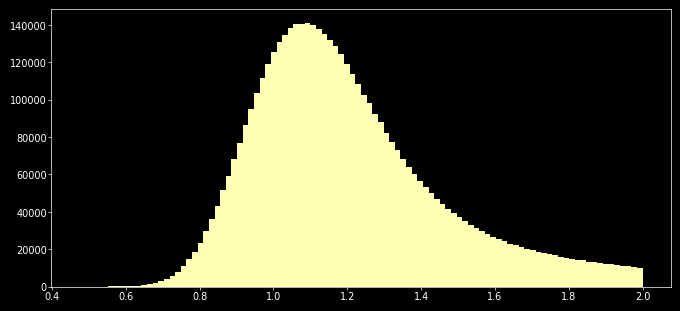

In [94]:
plt.hist(loc_data['chi_sqr'][loc_data['spot_matched_filter_response'] < 80], 100, density=False);
plt.hist(loc_data['chi_sqr'][loc_data['spot_matched_filter_response'] > 80], 100, density=False);

#plt.yscale('log')
plt.show()

In [82]:
np.median(loc_data['spot_matched_filter_response'])

166.4382

In [86]:
loc_data = loc_data[loc_data["xc_err"] < 1]
loc_data = loc_data[loc_data["yc_err"] < 1]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 1]
loc_data = loc_data[loc_data["s_y_err"] < 1]

loc_data = loc_data[loc_data["A_B_err"] < 0.15]
loc_data = loc_data[loc_data["A_G_err"] < 0.15]
loc_data = loc_data[loc_data["A_R_err"] < 0.15]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.01]
loc_data = loc_data[loc_data["A_R"] > 0.01]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

loc_data = loc_data[loc_data["photons"] < 100000]
loc_data = loc_data[loc_data["photons"] > 100]
#loc_data = loc_data[loc_data['spot_matched_filter_response'] > 80]

loc_data = loc_data[loc_data["chi_sqr"] < 2]

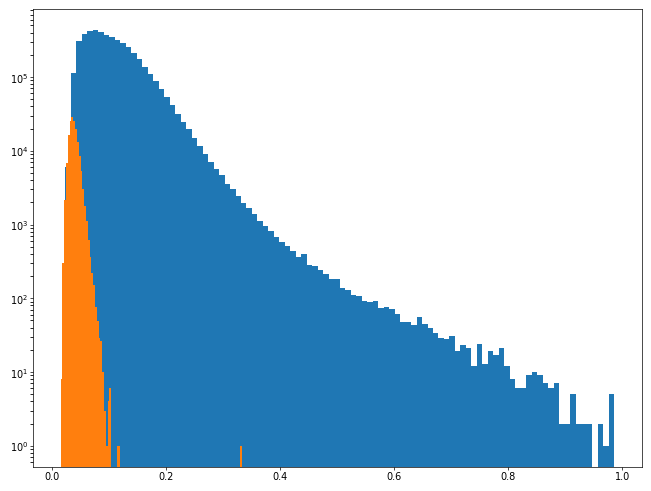

In [14]:
plt.hist(loc_data['xc_err'][loc_data['spot_matched_filter_response'] < 400], 100, density=False);
plt.hist(loc_data['xc_err'][loc_data['spot_matched_filter_response'] > 400], 100, density=False);

plt.yscale('log')
plt.show()

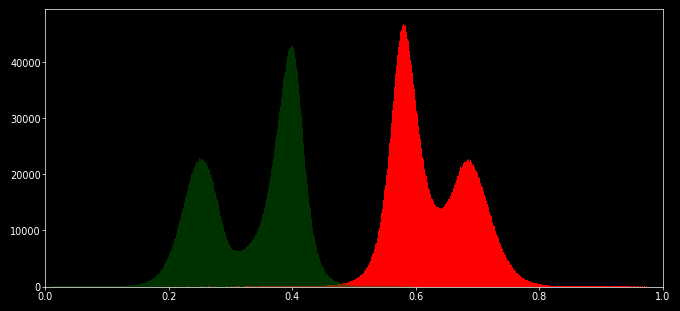

In [95]:
plt.hist(loc_data['A_R'], 1000, color='red');
plt.hist(loc_data['A_G'], 1000, alpha=0.5, color='darkgreen');
#plt.hist(loc_data['A_B'], 1000, alpha=0.5, color='lightblue');
plt.xlim([0, 1])
plt.show()

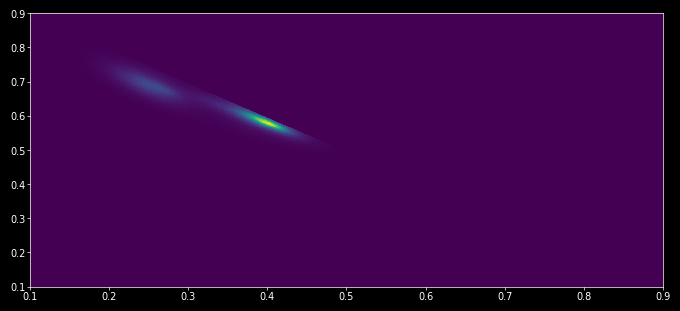

In [96]:
plt.hist2d(loc_data['A_G'], loc_data['A_R'], 1000);
plt.xlim([0.1, 0.9])
plt.ylim([0.1, 0.9])

# fit on two-D space
# initial guess in 1D space

plt.show()

In [17]:
image = render.render(
    locs=loc_data.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

In [97]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=20,
                                            intersect_d=20/69,
                                          roi_r=60/69,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)

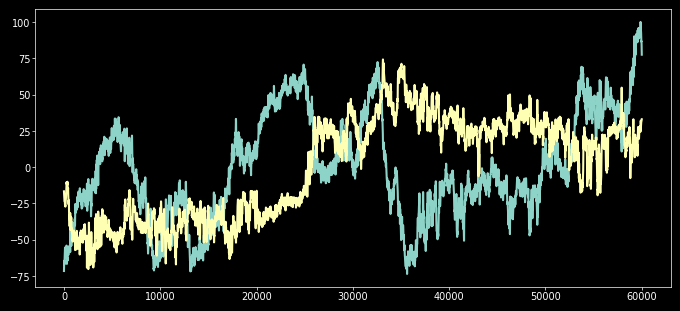

In [98]:
plt.plot(drift_result.drift_x*69)
plt.plot(drift_result.drift_y*69)

plt.show()

In [99]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

example_image = render.render(
            locs=corrected_locs.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

In [100]:
IO._write_h5_database(df=corrected_locs, filepath=localisation_files[0].split('.h5')[0]+'_Undrifted.h5', normalise_photons=False)

In [24]:
len(np.histogram_bin_edges(example_image.ravel(), 'sqrt'))

821

⚠️ Error creating separate plots: cannot access local variable 'plt' where it is not associated with a value


/home/jsb92/Documents/pyBayerSMLM/src/DriftPlotting.py:1179: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


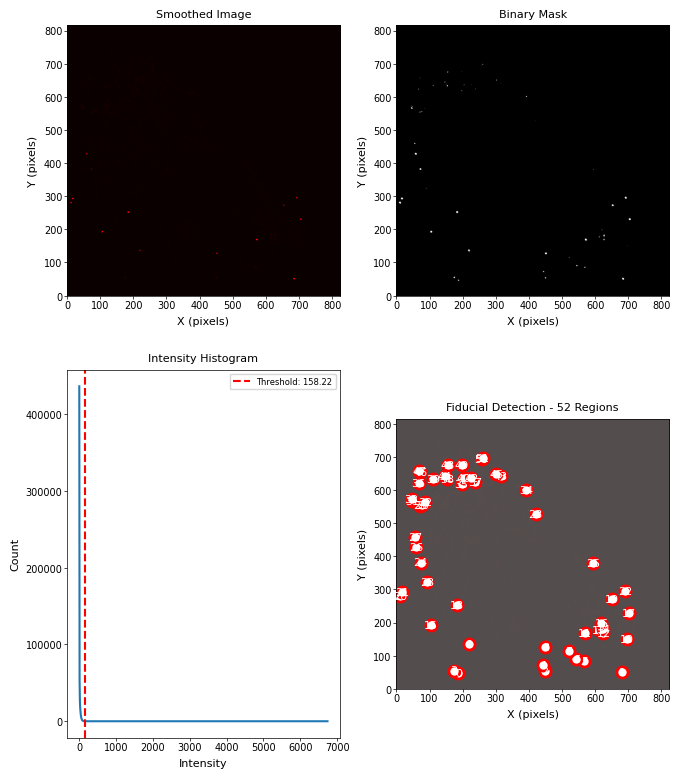

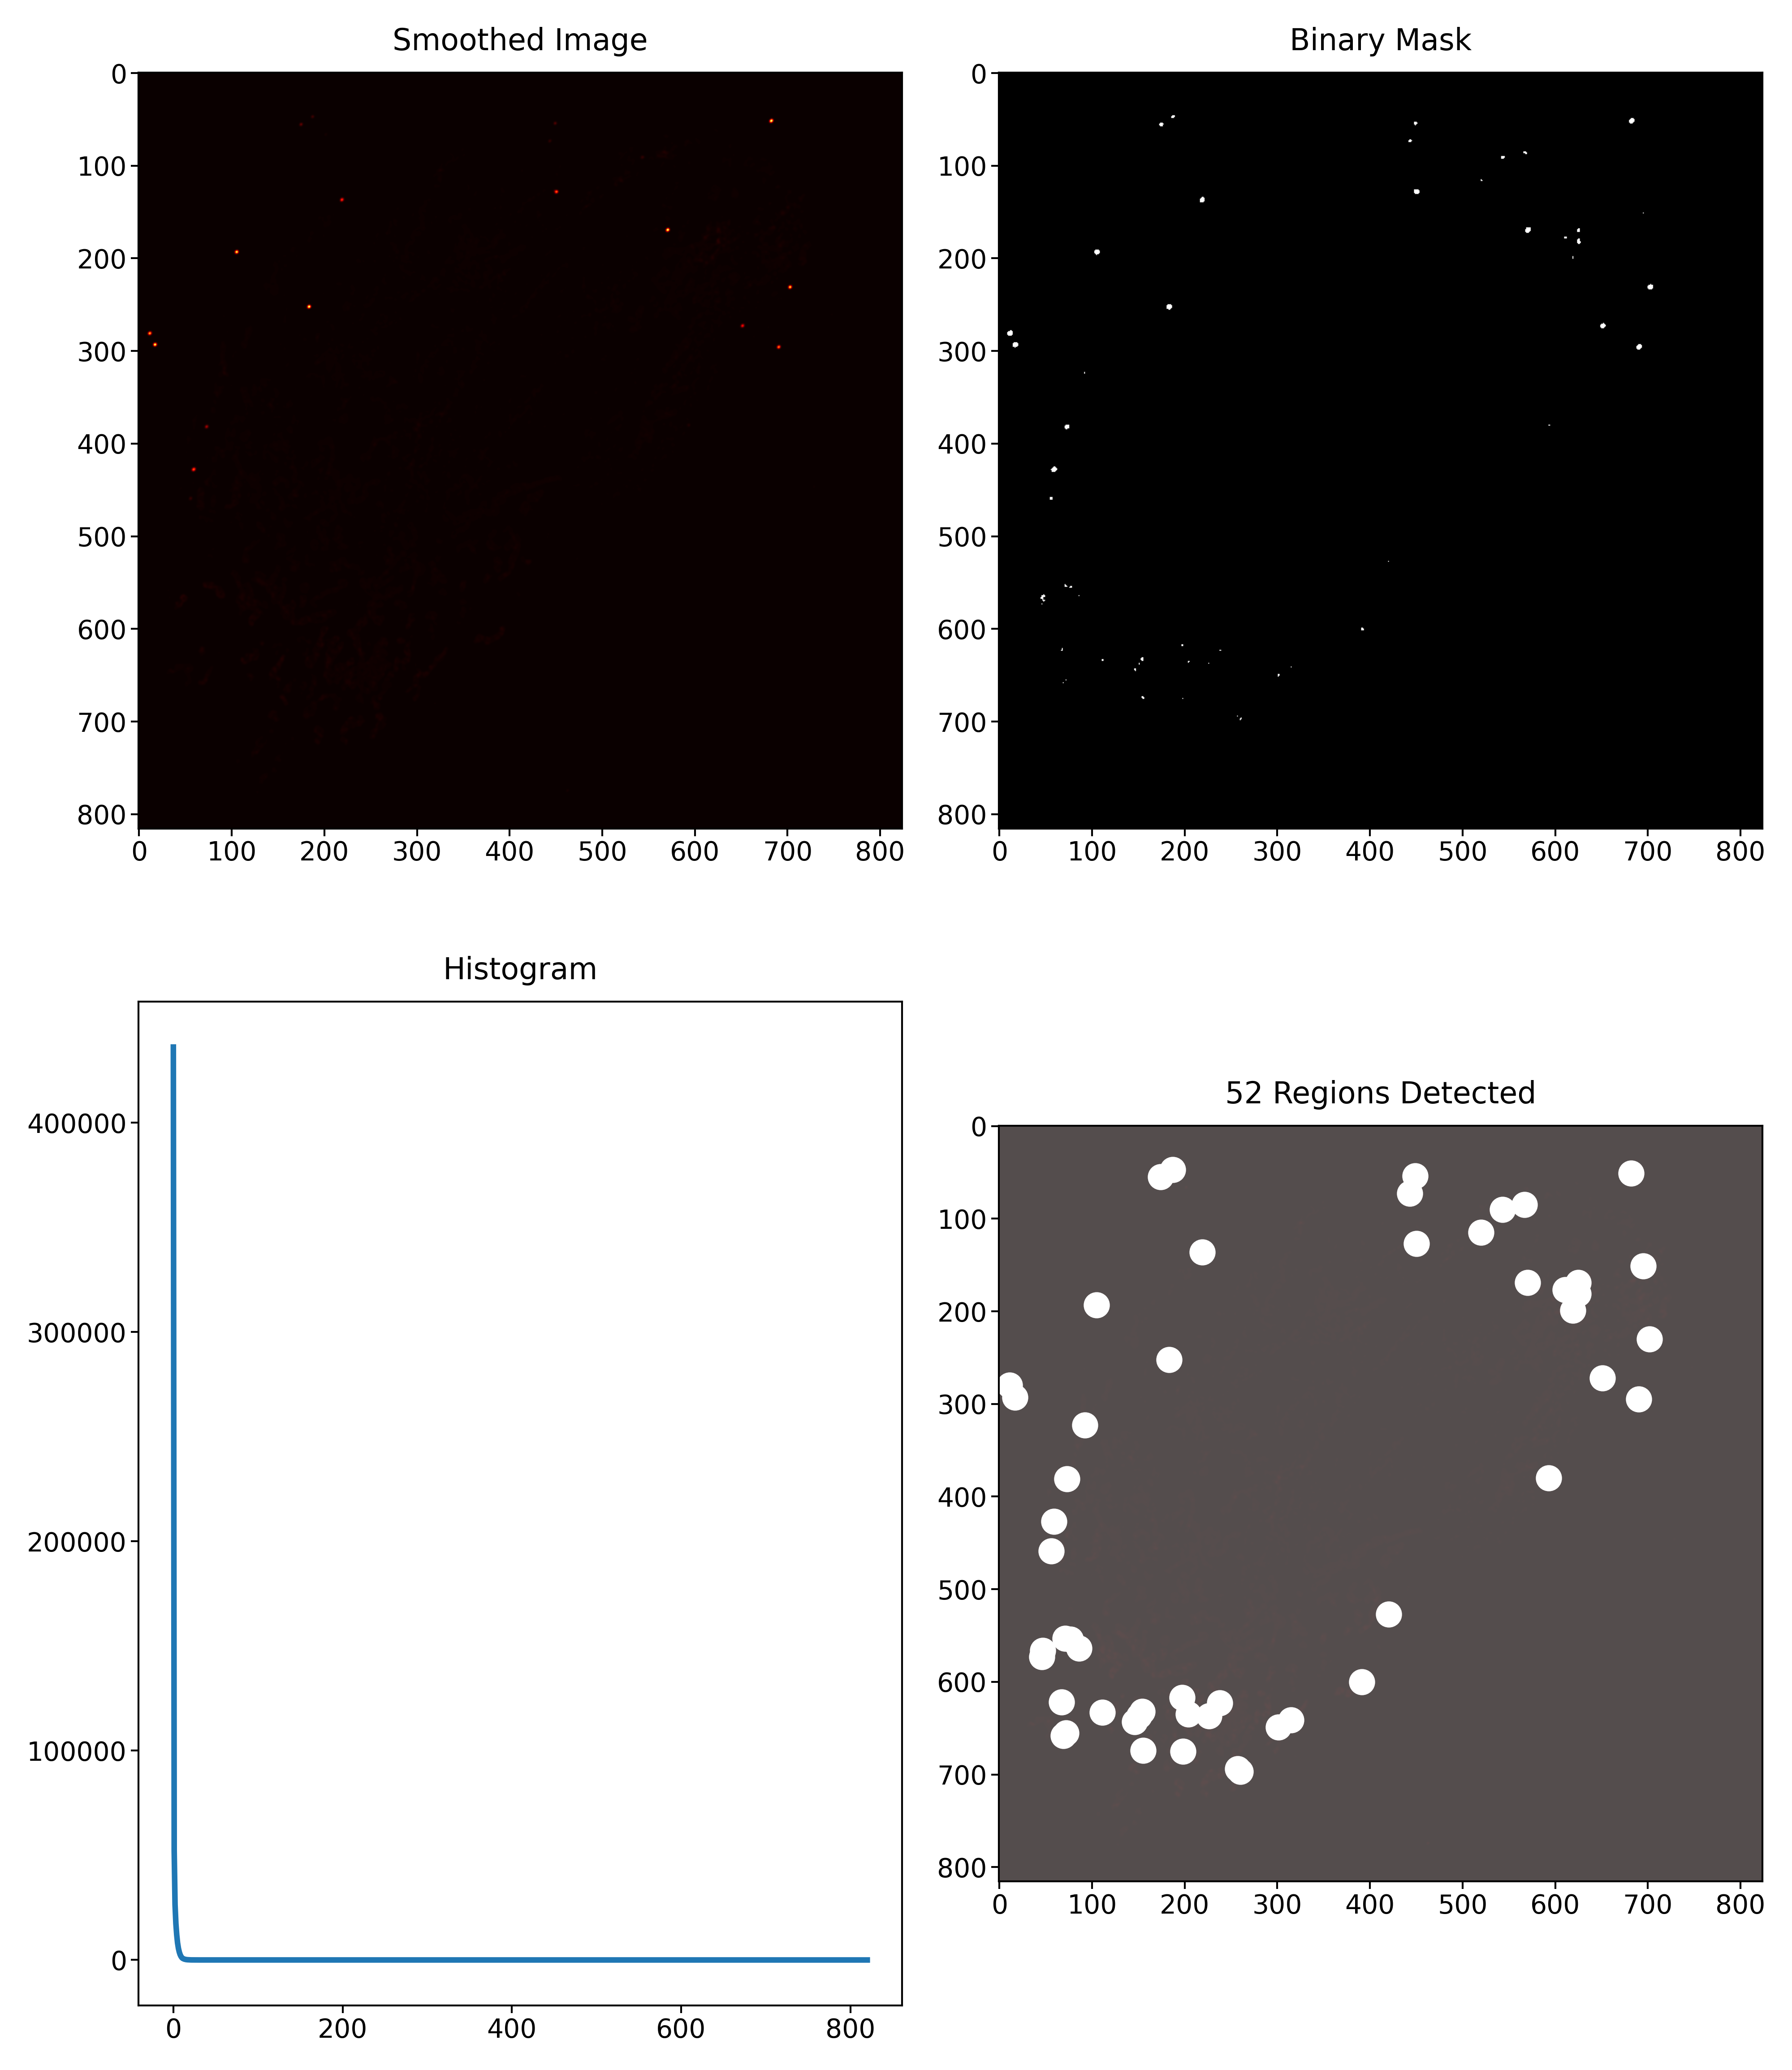

In [34]:
drift_corrector = DCF.Drift_Correction_Functions()

region_centers, binary_mask, threshold, metadata = drift_corrector.detect_high_density_regions_from_image(
      smoothed_image=example_image,
      histogram_bins=821,
      threshold_percentile=99.9,
      pixelsize=69.0,
      title="Fiducial Detection"
  )

Memory optimisation: Freed intermediate arrays after region processing          6.48it/s]


/home/jsb92/Documents/pyBayerSMLM/src/DriftPlotting.py:668: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


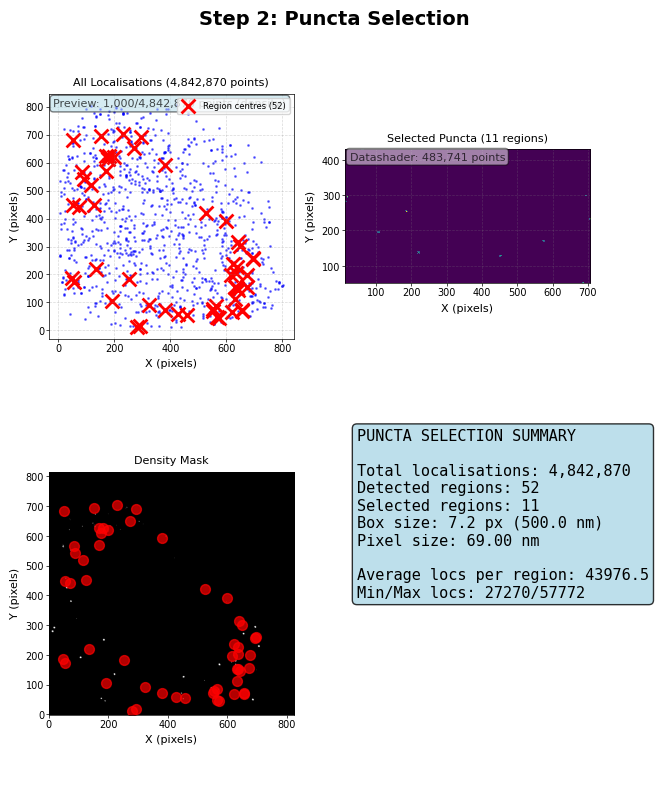

In [46]:
selected_puncta, selection_metadata = drift_corrector.select_puncta_from_regions(
        locs=corrected_locs.to_records(index=False),                             # Your localization data
        region_centres=region_centers,         # Output from Step 1
        binary_mask=binary_mask,               # Output from Step 1
        pixelsize=info[0]['Pixelsize'],
        selection_box_size_nm=500.0,         # Box size around each region center (adjust as needed)
        min_localisations_per_region=int(0.4*info[0]['Frames']),      # Minimum locs for valid fiducial (adjust as needed)
        title="Step 2: Puncta Selection",
        create_plot=True
    )

In [45]:
validated_fiducials, clustering_metadata = drift_corrector.identify_real_fiducials_with_clustering(
            selected_puncta=selected_puncta,
            min_samples_factor=0.25,    # Fraction of total frames (adjust as needed)
            retention_percentage = 0.7,
            frame_count=int(info[0]['Frames']),
            title="Fiducial Gaussian Fitting Analysis",
            create_plot=False
        )

Using radial threshold factor: 1.552 for 70.0% retention
  Fitting single Gaussian to 57772 points in region 0
  Fitting single Gaussian to 55114 points in region 1
  Fitting single Gaussian to 49706 points in region 2
  Fitting single Gaussian to 44904 points in region 3
  Fitting single Gaussian to 53342 points in region 4
  Fitting single Gaussian to 41522 points in region 5
  Fitting single Gaussian to 51359 points in region 6


In [38]:
final_corrected_locs, drift_info = drift_corrector.apply_validated_fiducial_drift_correction(corrected_locs.to_records(index=False),
                                                                                            validated_fiducials)

Final: 7/7 fiducials retained (0 removed)    

DEBUG: Drift calculation results:
  - Total unique frames in locs: 60000
  - drift_x type: <class 'numpy.ma.core.MaskedArray'>, shape: (60000,)
  - drift_y type: <class 'numpy.ma.core.MaskedArray'>, shape: (60000,)
  - mask_x sum (masked frames): 82
  - mask_y sum (masked frames): 82
  - valid_frame_mask sum: 59918
  - drift_x first 5 values: [0.0640193652151828 -0.1874040142868455 -0.06857151858034917
 -0.166823098342937 -0.10835526457368905]
  - drift_y first 5 values: [0.14764673910140072 0.08487880834804584 0.13550443123446998
 0.07661049520066382 0.05446154075415215]
Drift correction applied to 4836187 localisations
Used 59918 frames with fiducials (out of 60000 total frames)
Average 4.3 fiducials per frame


In [40]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

example_image = render.render(
            locs=corrected_locs.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

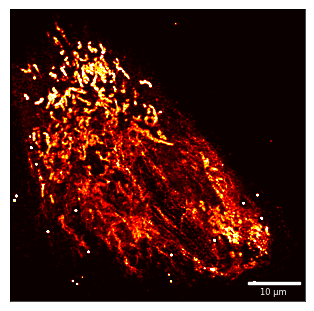

In [42]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, example_image, cmap='hot', cbar='off')

plt.show()

In [43]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

example_image_MF = render.render(
            locs=corrected_locs[corrected_locs['spot_matched_filter_response'] > 400].to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

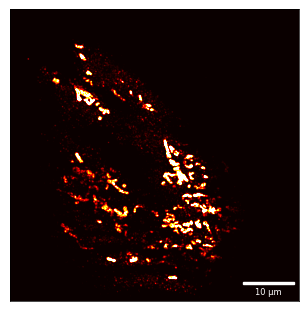

In [44]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, example_image_MF.T, cmap='hot', cbar='off', vmin=0)

plt.show()

In [ ]:
oversampling = 8
n_locs, image_DNA, image_DNA_spectral = render.render(
        locs=final_corrected_locs.to_records(index=False),
        oversampling=oversampling,
        info=info,
        blur_method="gaussian_colour",
        c_max = 1,
        c_min = 0.0,
        densitymin=0.05
    )

In [ ]:
just_PAINT = final_corrected_locs[final_corrected_locs['is_fiducial'] == 0]
IO._write_h5_database(df=just_PAINT, filepath=localisation_files[0].split('.h5')[0]+'_Undrifted_FiducialsRemoved.h5', normalise_photons=False)

In [ ]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]


n_locs, image_DNA, image_DNA_spectral = render.render(
        locs=just_PAINT.to_records(index=False),
        oversampling=oversampling,
        info=info,
        blur_method="gaussian_colour",
        c_max = 0.9,
        c_min = 0.5,
        densitymin=0.075
    )

In [ ]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, image_DNA_spectral, cbar='off')

plt.show()

In [ ]:
X = np.vstack([just_PAINT['xc'], just_PAINT['yc']]).T
loc_precision = 0.75*(np.mean(just_PAINT['xc_err']) + np.mean(just_PAINT['yc_err']))
hdb = DBSCAN(eps=loc_precision, min_samples=40)
hdb.fit(X)

In [ ]:
len(np.unique(hdb.labels_))

In [ ]:
test = just_PAINT[hdb.labels_ > -1]

In [ ]:
oversampling = 1
n_locs, image_DNA, image_DNA_spectral = render.render(
        locs=test.to_records(index=False),
        oversampling=oversampling,
        info=info,
        blur_method="gaussian_colour",
        c_max = 0.9,
        c_min = 0.5,
        densitymin=0.05
    )

In [ ]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, image_DNA_spectral, cbar='off')

plt.show()

In [ ]:
IO._write_h5_database(df=just_PAINT, filepath=localisation_files[0].split('.h5')[0]+'_Undrifted.h5', normalise_photons=False,
                      append=False)

In [48]:
# ============================================================================
# Channel Unmixing Test
# ============================================================================

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

Channel Unmixing
Input: 4842870 localizations
Channels: 2
Features: ['A_R', 'A_G']

Feature matrix: (4842870, 2)
Feature ranges:
  A_R: [0.014, 0.985], mean=0.625
  A_G: [0.010, 0.925], mean=0.336

Finding initial channel means (method: histogram_peaks)...
Initial means:
  Channel 0: A_R=0.587, A_G=0.403
  Channel 1: A_R=0.684, A_G=0.257

Estimating initial covariances from core regions (conservative)...
  Channel 0: det(cov)=0.000000, σ1=0.006, σ2=0.011
  Channel 1: det(cov)=0.000000, σ1=0.008, σ2=0.014



/home/jsb92/Documents/pyBayerSMLM/notebooks/superres_dna_paint_cells/../../src/SM_extractionfunctions.py:3828: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)  # Make room for colorbar


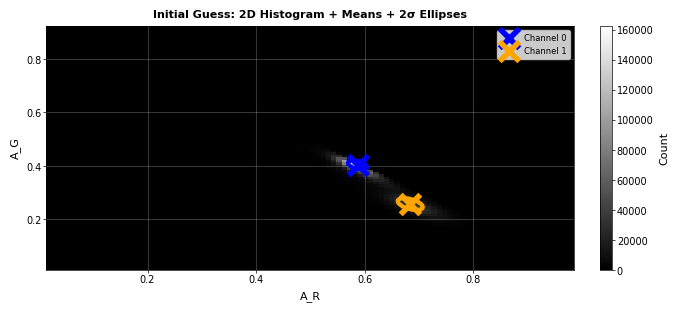

Fitting GMM (method: fixed, covariance: full)...
  Error columns available (mean errors: [ 0.00070138  0.00059741])
Using fixed initial guess (no EM refinement)
GMM fitting: converged
Fitted means:
  Channel 0: A_R=0.587, A_G=0.403 (weight: 59.1%)
  Channel 1: A_R=0.684, A_G=0.257 (weight: 40.9%)

Calculating posterior probabilities and assignments...
Calculating analytical FPR to determine confidence threshold (target: 0.050)...
Analytical accuracy: 1.000
Confusion matrix:
[[ 1.  0.]
 [ 0.  1.]]

Setting confidence threshold to 0.975 (from FPR=0.050)
Applying Mahalanobis distance outlier rejection...
  Outliers detected: 1862293 (38.45%, threshold=3.72)

Unmixing Complete
Assignments:
  Channel 0: 1,738,220 (35.9%)
  Channel 1: 1,200,087 (24.8%)
  Unassigned: 1,904,563 (39.3%)



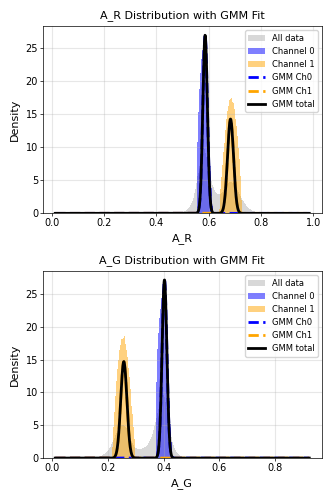

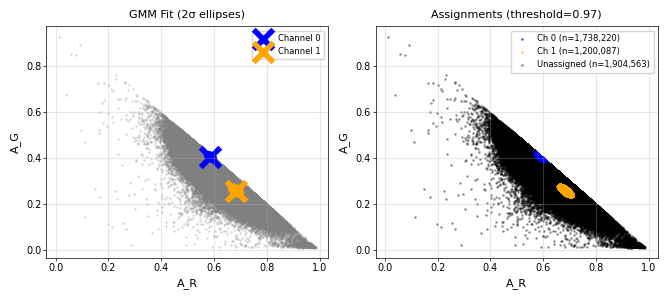

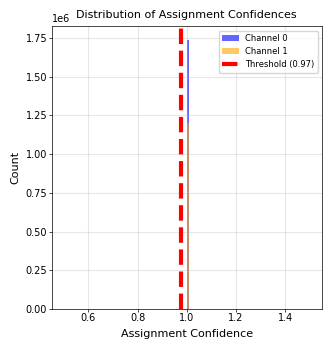

/home/jsb92/Documents/pyBayerSMLM/notebooks/superres_dna_paint_cells/../../src/SM_extractionfunctions.py:4007: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)  # Make room for colorbar


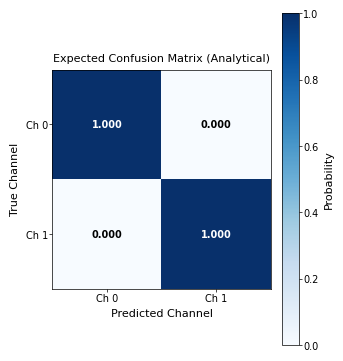

In [50]:
# Test channel unmixing on the filtered loc_data
# This data has ATTO655 (red) and Cy3B (green)

assigned_locs, metadata = SM_E.unmix_channels(
    corrected_locs,
    n_channels=2,
    channels_to_use=['A_R', 'A_G'],
    confidence_threshold=0.95,  # Start with 95% confidence
    false_positive_rate=0.05,
    initial_guess_method='histogram_peaks',
    gmm_fit_method='fixed',
    covariance_type='full',
    outlier_rejection='mahalanobis',
    mestimator_type='tukey',
    initial_guess_percentile=50,
    initial_guess_scale=0.5,
    verbose=True,
    plot_results=True
)

In [ ]:
np.unique(assigned_locs['channel'])

In [53]:
oversampling = 8

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image_DL = render.render(
            locs=assigned_locs[(assigned_locs['channel'] == 0) | (assigned_locs['channel'] == 1) | (assigned_locs['frame'] <= 20000)].to_records(index=False),
            info=info,
            blur_method="gaussian",
            oversampling=oversampling,
            min_blur_width=PSF.sigma_PSF(wavelength=600, NA=1.49)/69
        )[1]  # Take the rendered image

/tmp/ipykernel_1176730/1561919806.py:5: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=True)


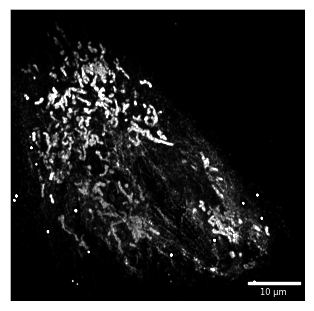

In [54]:
from PlottingBase import PublicationPlotter

pixel_size = 69
# Create overlay
plotter = PlottingFunctions.Plotter(dark_background=True)
fig, ax = plotter.two_column_plot()

axs = plotter.image_plot(
  ax, image_DL,
  pixelsize=(pixel_size/oversampling),
  scalebarsize=10000,
  scalebarlabel='10 μm',
  cbar='off',
)


#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Group Meeting/20251201/fig/multicolour_camera/Massive_Cells_PAINT/'
#plt.savefig(os.path.join(folder, 'Massive_Cells_DL_Render.svg'), dpi=600, format='svg')
plt.show()

In [55]:
channel_0 = assigned_locs[assigned_locs['channel'] == 0]

X = np.vstack([channel_0['xc'], channel_0['yc']]).T
loc_precision = 3*(np.median(channel_0['xc_err']) + np.median(channel_0['yc_err']))
hdb = DBSCAN(eps=loc_precision, min_samples=10)
hdb.fit(X)

,eps,0.40396490693092346
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [56]:
channel_0_pruned = channel_0[hdb.labels_ > -1]
channel_0_pruned['label'] = hdb.labels_[hdb.labels_ > -1]

/tmp/ipykernel_1176730/483749982.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  channel_0_pruned['label'] = hdb.labels_[hdb.labels_ > -1]


In [57]:
channel_1 = assigned_locs[assigned_locs['channel'] == 1]

X = np.vstack([channel_1['xc'], channel_1['yc']]).T
loc_precision = 3*(np.median(channel_1['xc_err']) + np.median(channel_1['yc_err']))
hdb = DBSCAN(min_samples=10)
hdb.fit(X)

,eps,0.5
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [58]:
channel_1_pruned = channel_1[hdb.labels_ > -1]
channel_1_pruned['label'] = hdb.labels_[hdb.labels_ > -1]

/tmp/ipykernel_1176730/2822060287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  channel_1_pruned['label'] = hdb.labels_[hdb.labels_ > -1]


In [106]:
min_blur_width=PSF.sigma_PSF(wavelength=600, NA=1.49)/69
print(min_blur_width)

1.3135633442618997


In [119]:
oversampling = 8
pixel_size = 69

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": pixel_size,        # pixel size always in nm
}]

# Render two channels
_, img1 = render.render(channel_0.to_records(index=False), info, oversampling=oversampling, blur_method='gaussian')
_, img2 = render.render(channel_1.to_records(index=False), info, oversampling=oversampling, blur_method='gaussian')


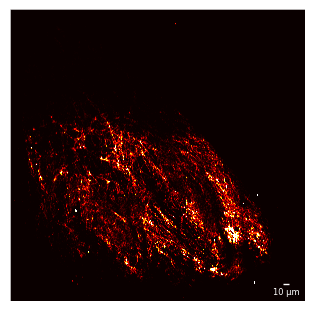

In [122]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, img2, cmap='hot', vmin=np.percentile(img2, 1), vmax=np.percentile(img2, 99.5), cbar='off')

plt.show()

/tmp/ipykernel_1176730/3350816508.py:5: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=True)


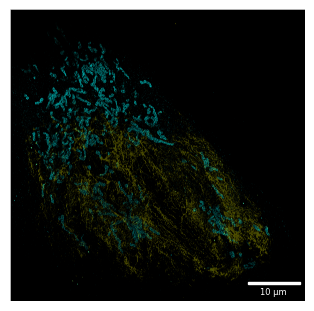

In [115]:
from PlottingBase import PublicationPlotter


# Create overlay
plotter = PlottingFunctions.Plotter(dark_background=True)
fig, ax = plotter.two_column_plot()

ax = plotter.multichannel_overlay_plot(
  ax, [img2, img1],
  cmaps=['yellow', 'cyan'],
  pixelsize=(pixel_size/oversampling),
  scalebarsize=10000,
  alphas=[1, 0.7],
  vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
  vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
  brightness_boost=[2, 1],
  scalebarlabel='10 μm'
)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, 'Massive_Cells_Render.svg'), dpi=600, format='svg')
plt.show()

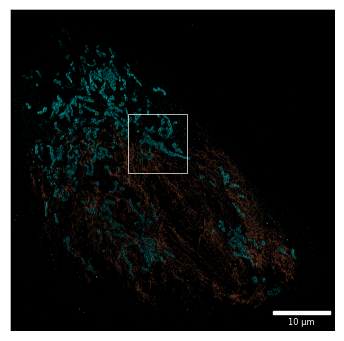

In [78]:
from PlottingBase import PublicationPlotter


# Create overlay
plotter = PublicationPlotter()
fig, ax = plotter.create_figure()

plotter.multichannel_overlay_plot(
  ax, [img2, img1],
  cmaps=['coral', 'cyan'],
  pixelsize=(pixel_size/oversampling),
  scalebarsize=10000,
  alphas=[1, 0.7],
  vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
  vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
  brightness_boost=[2, 1],
  scalebarlabel='10 μm'
)
import matplotlib.patches as patches

rect = patches.Rectangle(
    (300 * oversampling, 400 * oversampling),
    150 * oversampling,
    150 * oversampling,
    linewidth=0.5,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
ax.add_patch(rect)


folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, 'Massive_Cells_Render_Under30k_Box.svg'), dpi=600, format='svg')
plt.show()

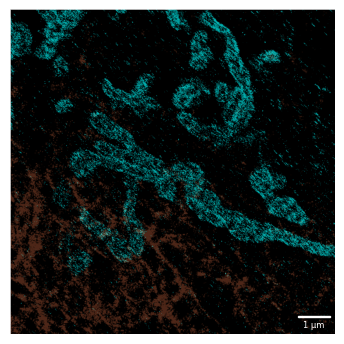

In [79]:
from PlottingBase import PublicationPlotter


# Create overlay
plotter = PublicationPlotter()
fig, ax = plotter.create_figure()

img1_subset = img1[int(400 * oversampling):int((400+150) * oversampling), int(300 * oversampling):int((300+150) * oversampling)]
img2_subset = img2[int(400 * oversampling):int((400+150) * oversampling), int(300 * oversampling):int((300+150) * oversampling)]


plotter.multichannel_overlay_plot(
  ax, [img2_subset, img1_subset],
  cmaps=['coral', 'cyan'],
  pixelsize=(pixel_size/oversampling),
  scalebarsize=1000,
  alphas=[1, 0.7],
  vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
  vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
  brightness_boost=[2, 1],
  scalebarlabel='1 μm'
)


folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, 'Massive_Cells_Render_Under30k_Zoomin.svg'), dpi=600, format='svg')
plt.show()

In [ ]:
plt.hist(loc_data['xc_err']*69,1000)
plt.show()

In [ ]:
assigned_locs, metadata = SM_E.unmix_channels_with_spatial_refinement(loc_data,
                                                                 n_channels=2,
                                                                 channels_to_use=['A_R', 'A_G'],
                                                                 plot_results=True)

In [ ]:
assigned_locs_HDBScan, metadata_HDBScan = SM_E.unmix_channels_with_spatial_refinement(loc_data,
                                                                 n_channels=2,
                                                                 channels_to_use=['A_R', 'A_G'],
                                                                 spatial_method='HDBSCAN',
                                                                 min_cluster_size=50,
                                                                 plot_results=True)

In [ ]:
channel_1_pruned = assigned_locs_HDBScan[assigned_locs_HDBScan['channel'] == 1]
channel_0_pruned = assigned_locs_HDBScan[assigned_locs_HDBScan['channel'] == 0]


In [ ]:
oversampling = 8
pixel_size = 69

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": pixel_size,        # pixel size always in nm
}]

# Render two channels
_, img1 = render.render(channel_0_pruned.drop('assignment_stage', axis=1).to_records(index=False), info, oversampling=oversampling, blur_method='gaussian')
_, img2 = render.render(channel_1_pruned.drop('assignment_stage', axis=1).to_records(index=False), info, oversampling=oversampling, blur_method='gaussian')


In [ ]:
from PlottingBase import PublicationPlotter


# Create overlay
plotter = PublicationPlotter()
fig, ax = plotter.create_figure()

plotter.multichannel_overlay_plot(
  ax, [img2, img1],
  cmaps=['coral', 'cyan'],
  pixelsize=(pixel_size/oversampling),
  scalebarsize=10000,
  alphas=[1, 0.7],
  vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
  vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
  brightness_boost=[2, 1],
  scalebarlabel='10 μm'
)

#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20251104_Geneva/fig/multicolour_camera/Massive_Cells_PAINT/'
#plt.savefig(os.path.join(folder, 'Massive_Cells_HDBSCANRender.svg'), dpi=600, format='svg')
plt.show()

In [ ]:
channel_1_pruned = assigned_locs[assigned_locs['channel'] == 1]
channel_0_pruned = assigned_locs[assigned_locs['channel'] == 0]

oversampling = 8
pixel_size = 69

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": pixel_size,        # pixel size always in nm
}]

# Render two channels
_, img1 = render.render(channel_0_pruned.drop('assignment_stage', axis=1).to_records(index=False), info, oversampling=oversampling, blur_method='gaussian')
_, img2 = render.render(channel_1_pruned.drop('assignment_stage', axis=1).to_records(index=False), info, oversampling=oversampling, blur_method='gaussian')



In [ ]:
from PlottingBase import PublicationPlotter


# Create overlay
plotter = PublicationPlotter()
fig, ax = plotter.create_figure()

plotter.multichannel_overlay_plot(
  ax, [img2, img1],
  cmaps=['coral', 'cyan'],
  pixelsize=(pixel_size/oversampling),
  scalebarsize=10000,
  alphas=[1, 0.7],
  vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
  vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
  brightness_boost=[2, 1],
  scalebarlabel='10 μm'
)

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20251104_Geneva/fig/multicolour_camera/Massive_Cells_PAINT/'
plt.savefig(os.path.join(folder, 'Massive_Cells_DBSCANRender.svg'), dpi=600, format='svg')
plt.show()